In [ ]:
!pip install qiskit qiskit_aer --quiet
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Gate
from qiskit_aer import AerSimulator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Colab Notebooks

/content/drive/MyDrive/Colab Notebooks


[True Markovian] Step 1 | S(R) ≈ 1.0000
[True Markovian] Step 2 | S(R) ≈ 2.0000
[True Markovian] Step 3 | S(R) ≈ 3.0000
[True Markovian] Step 4 | S(R) ≈ 4.0000
[True Markovian] Step 5 | S(R) ≈ 5.0000
[True Markovian] Step 6 | S(R) ≈ 6.0000
[True Markovian] Step 7 | S(R) ≈ 7.0000
[True Markovian] Step 8 | S(R) ≈ 8.0000
[Non-Markovian] Step 1 | S(R) = 0.9963
[Non-Markovian] Step 2 | S(R) = 1.9826
[Non-Markovian] Step 3 | S(R) = 2.9618
[Non-Markovian] Step 4 | S(R) = 3.8165
[Non-Markovian] Step 5 | S(R) = 4.3002
[Non-Markovian] Step 6 | S(R) = 3.8194
[Non-Markovian] Step 7 | S(R) = 2.9533
[Non-Markovian] Step 8 | S(R) = 1.9917


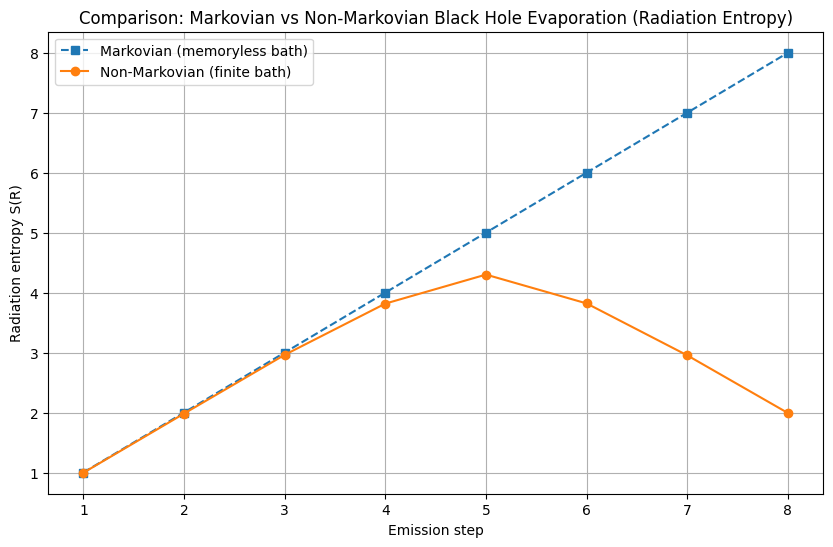

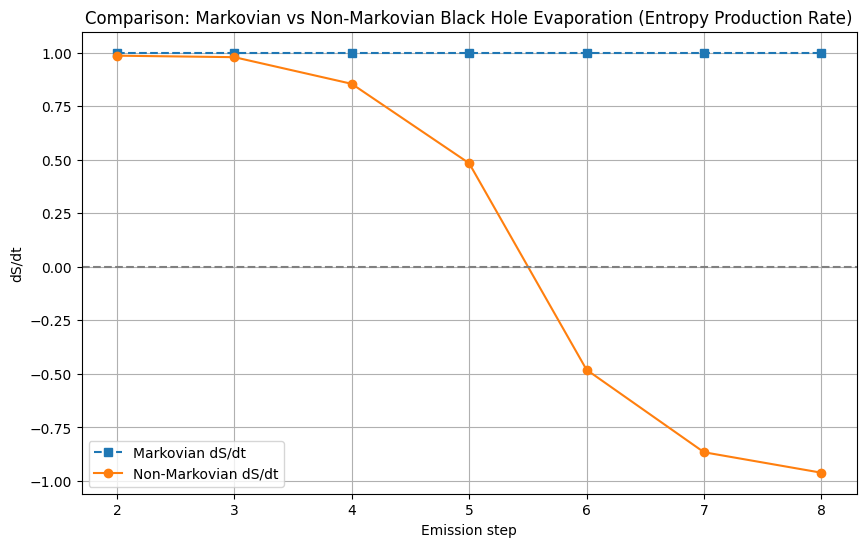

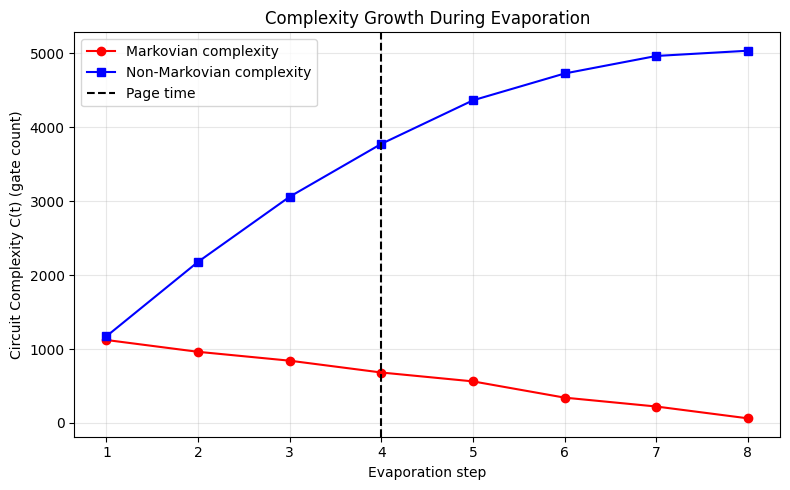

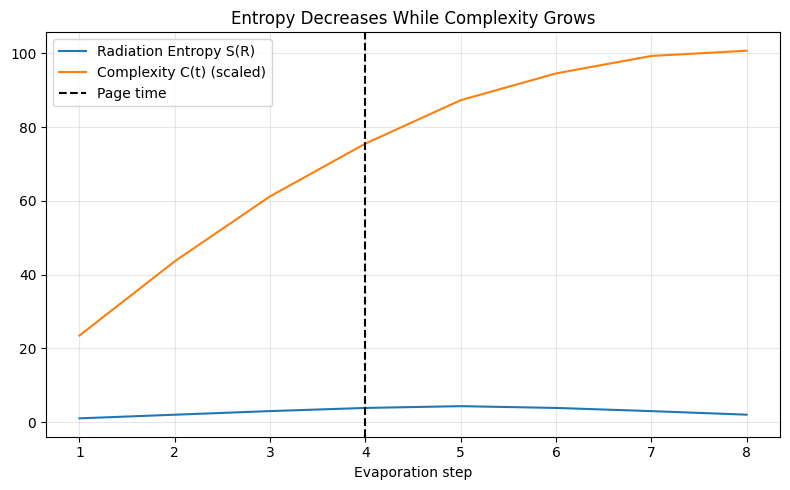

In [ ]:
%run MvNM_base.ipynb

Simulating discrete BH-to-Environment OTOC on 11 qubits for 10 iterations...

--- Running Iteration 1/10 ---
Step 0 | Re[OTOC] = 1.0000
Step 1 | Re[OTOC] = 0.1455
Step 2 | Re[OTOC] = 0.0420
Step 3 | Re[OTOC] = -0.0361
Step 4 | Re[OTOC] = -0.0254
Step 5 | Re[OTOC] = 0.0156
Step 6 | Re[OTOC] = -0.0137

--- Running Iteration 2/10 ---
Step 0 | Re[OTOC] = 1.0000
Step 1 | Re[OTOC] = 0.1826
Step 2 | Re[OTOC] = 0.0547
Step 3 | Re[OTOC] = -0.0732
Step 4 | Re[OTOC] = -0.0176
Step 5 | Re[OTOC] = 0.0225
Step 6 | Re[OTOC] = 0.0137

--- Running Iteration 3/10 ---
Step 0 | Re[OTOC] = 1.0000
Step 1 | Re[OTOC] = 0.1914
Step 2 | Re[OTOC] = 0.0977
Step 3 | Re[OTOC] = -0.0303
Step 4 | Re[OTOC] = 0.0000
Step 5 | Re[OTOC] = -0.0107
Step 6 | Re[OTOC] = 0.0010

--- Running Iteration 4/10 ---
Step 0 | Re[OTOC] = 1.0000
Step 1 | Re[OTOC] = 0.1523
Step 2 | Re[OTOC] = 0.0693
Step 3 | Re[OTOC] = -0.0840
Step 4 | Re[OTOC] = -0.0527
Step 5 | Re[OTOC] = -0.0293
Step 6 | Re[OTOC] = 0.0391

--- Running Iteration 5/10 -

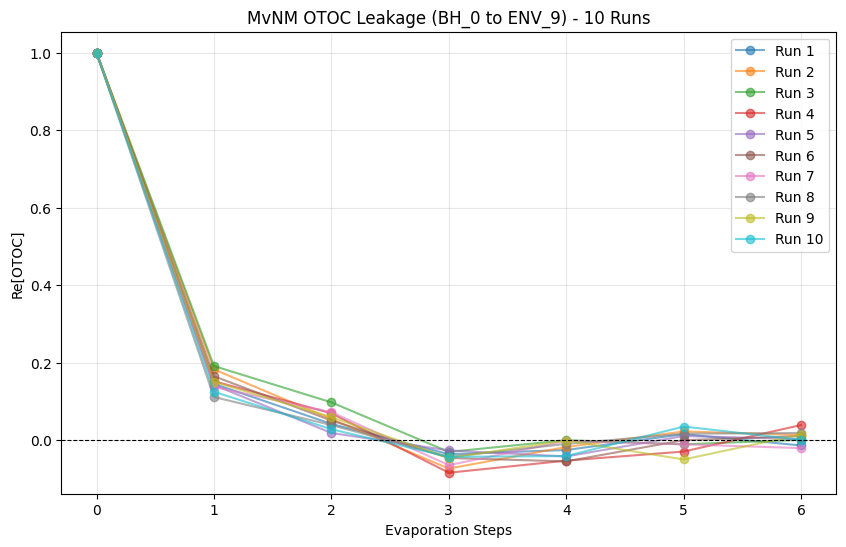

In [ ]:
# 2. Setup OTOC System Size
ancilla_qubit_index = TOTAL_QUBITS # Index 12 (the 13th qubit)
otoc_total_qubits = TOTAL_QUBITS + 1

# 3. FREEZE THE DYNAMICS (The Randomness Fix)
# We must generate the random angles ONCE to ensure U_dag perfectly reverses U
step_qc = QuantumCircuit(TOTAL_QUBITS, name="U_NvNM_step")

bh_qubits = list(range(N_BH))
env_qubits = list(range(N_BH, TOTAL_QUBITS))

# Apply one discrete step of your exact NvNM dynamics
scramble_black_hole(step_qc, bh_qubits)
evolve_environment(step_qc, env_qubits)
bh_environment_interaction(step_qc, bh_qubits, env_qubits)

# Convert to fixed gates
U_step_gate = step_qc.to_gate()
U_step_dag_gate = U_step_gate.inverse()

# 4. Simulation Loop
simulator = AerSimulator()
shots = 2048

# We only need a few steps because 20 layers of scrambling is extremely fast
max_steps = 6
time_steps = list(range(max_steps + 1))

# --- New: Multiple Iterations Setup ---
num_iterations = 10  # Define how many times to run the simulation
all_otoc_values = [] # List to store otoc_values from each iteration

print(f"Simulating discrete BH-to-Environment OTOC on {otoc_total_qubits} qubits for {num_iterations} iterations...")

for iteration in range(num_iterations):
    otoc_values = []
    print(f"\n--- Running Iteration {iteration + 1}/{num_iterations} ---")

    for step in time_steps:
        qc = QuantumCircuit(otoc_total_qubits, 1)
        qc.h(ancilla_qubit_index)

        sys_qubits = list(range(TOTAL_QUBITS))

        # --- The Leakage OTOC Sequence ---
        # V on Qubit 0 (Deep inside Black Hole)
        qc.cz(ancilla_qubit_index, 0)

        # Forward Time Evolution (apply 'step' times)
        for _ in range(step):
            qc.append(U_step_gate, sys_qubits)

        # W on the last Environment Qubit (Edge of the radiation bath)
        w_index = TOTAL_QUBITS - 1
        qc.x(w_index)

        # Backward Time Evolution
        for _ in range(step):
            qc.append(U_step_dag_gate, sys_qubits)

        # V_dag
        qc.cz(ancilla_qubit_index, 0)

        # Forward Time
        for _ in range(step):
            qc.append(U_step_gate, sys_qubits)

        # W_dag
        qc.x(w_index)

        # Backward Time
        for _ in range(step):
            qc.append(U_step_dag_gate, sys_qubits)
        # ---------------------------------

        # Measure
        qc.h(ancilla_qubit_index)
        qc.measure(ancilla_qubit_index, 0)

        # Run
        qc_flat = qc.decompose()
        qc_transpiled = transpile(qc_flat, simulator)
        result = simulator.run(qc_transpiled, shots=shots).result()
        counts = result.get_counts()

        p_0 = counts.get('0', 0) / shots
        otoc_real = 2 * p_0 - 1
        otoc_values.append(otoc_real)
        print(f"Step {step} | Re[OTOC] = {otoc_real:.4f}")

    all_otoc_values.append(otoc_values)

# 5. Plotting
plt.figure(figsize=(10, 6))
for i, values in enumerate(all_otoc_values):
    plt.plot(time_steps, values, marker='o', linestyle='-', alpha=0.6, label=f'Run {i+1}')

plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title(f"MvNM OTOC Leakage (BH_0 to ENV_{TOTAL_QUBITS-1}) - {num_iterations} Runs")
plt.xlabel("Evaporation Steps")
plt.ylabel("Re[OTOC]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()